In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42  # TrueType
mpl.rcParams['ps.fonttype'] = 42   # TrueType

# Plot saved results

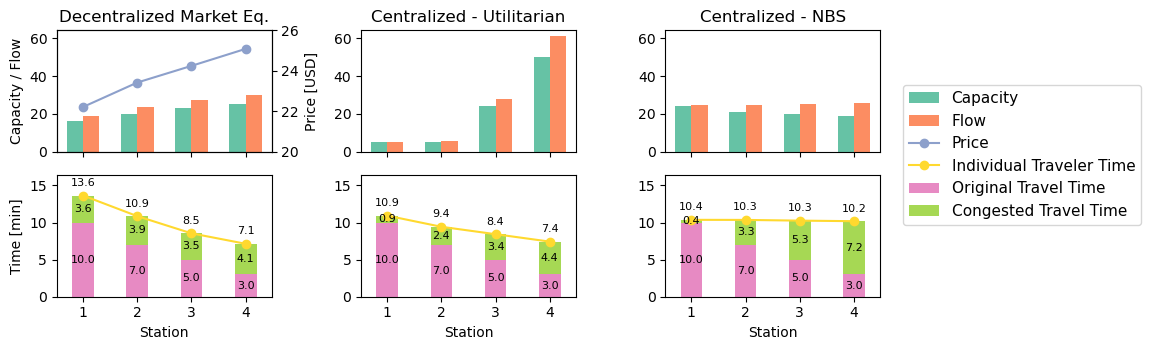

In [3]:
import json
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------- #
# Helper functions
# ------------------------- #

def load_results(filename):
    """Load results JSON and extract key metrics."""
    with open(filename + ".json") as f:
        results = json.load(f)

    stations = list(results["capacities"].keys())
    capacities = list(results["capacities"].values())
    flows = list(results["flows"].values())
    travel_time = list(results["travel_time"].values())
    prices = list(results["prices"].values())
    T_j0 = list(results["T_j0"].values())

    original_travel_time = [T_j0[i] for i in range(len(stations))]
    congest_travel_time = [travel_time[i] - original_travel_time[i] for i in range(len(stations))]

    return stations, capacities, flows, travel_time, prices, original_travel_time, congest_travel_time


def plot_capacity_flow(ax, stations, capacities, flows, colormap, prices = None, title=None):
    """Bar plot of capacity vs. flow."""
    width = 0.3
    x = range(len(stations))
    ax.bar([i - width/2 for i in x], capacities, width, label="Capacity", color=colormap[0])
    ax.bar([i + width/2 for i in x], flows, width, label="Flow", color=colormap[1])
    handles, labels = ax.get_legend_handles_labels()

    if prices: 
        ax2 = ax.twinx()  # Create a second y-axis for prices
        ax2.plot(stations, prices, label="Price", color=colormap[2], marker='o')
        ax2.set_ylabel("Price [USD]")
        ax2.set_ylim(20,26)
        # include ax2 legend and return with ax legend
        handles2, labels2 = ax2.get_legend_handles_labels()
        handles.extend(handles2)
        labels.extend(labels2)
        

    if title:
        ax.set_title(title, fontsize=12)
    
    return handles, labels


def plot_time_breakdown(ax, stations, orig_time, cong_time, total_time, colormap, title=None):
    """Stacked bar + line plot of travel times."""
    ax.bar(stations, orig_time, label="Original Travel Time", color=colormap[3], width=0.4)
    ax.bar(stations, cong_time, bottom=orig_time, label="Congested Travel Time", color=colormap[4], width=0.4)
    ax.plot(stations, total_time, label="Individual Traveler Time", color=colormap[5], marker='o')

    # Add text labels
    for i, s in enumerate(stations):
        ax.text(s, orig_time[i]/2, f"{orig_time[i]:.1f}", ha='center', va='center', fontsize=8)
        ax.text(s, orig_time[i] + cong_time[i]/2, f"{cong_time[i]:.1f}", ha='center', va='center', fontsize=8)
        ax.text(s, total_time[i] + 1, f"{total_time[i]:.1f}", ha='center', va='bottom', fontsize=8)

    if title:
        ax.set_title(title, fontsize=10, loc="left", x=0.05, y=0.8)


# ------------------------- #
# Main plotting
# ------------------------- #

colormap = sns.color_palette("Set2", 8)
fig, ax = plt.subplots(2, 3, figsize=(9, 4), sharex=True)
ax[0,1].sharey(ax[0,0]); ax[0,2].sharey(ax[0,0])
ax[1,1].sharey(ax[1,0]); ax[1,2].sharey(ax[1,0])
ax = ax.ravel()

# ----- Case 1: Decentralized Market Eq. -----
stations, caps, flows, tt, prices, t0, cong = load_results(
    "results_final/nash/NASH_lam0.6_tau0.5_alpha20_oper5_fix15_maxcap100_tax0_0_0_0"
)

handles, labels = plot_capacity_flow(ax[0], stations, caps, flows, colormap, prices, title="Decentralized Market Eq.")
plot_time_breakdown(ax[3], stations, t0, cong, tt, colormap)

ax[0].set_ylabel("Capacity / Flow")
ax[3].set_ylabel("Time [min]")
ax[3].set_ylim(0, max(tt)*1.2)

travel_time1 = [tt[i] * flows[i] for i in range(len(flows))]
travel_cost1 = [prices[i] * flows[i] for i in range(len(flows))]

# ----- Case 2: Centralized - Utilitarian -----
stations, caps, flows, tt, prices, t0, cong = load_results(
    "results_final/global/flow_global_opt_utilitarian_tau0.5_alpha20_oper5_fix15_maxcap84"
)
plot_capacity_flow(ax[1], stations, caps, flows, colormap, title="Centralized - Utilitarian")
plot_time_breakdown(ax[4], stations, t0, cong, tt, colormap)

travel_time2 = [tt[i] * flows[i] for i in range(len(flows))]
travel_cost2 = [prices[i] * flows[i] for i in range(len(flows))]


# ----- Case 3: Centralized - NBS -----
stations, caps, flows, tt, prices, t0, cong = load_results(
    "results_final/global/flow_global_opt_NBS_tau0.5_alpha20_oper5_fix15_maxcap84"
)
plot_capacity_flow(ax[2], stations, caps, flows, colormap, title="Centralized - NBS")
plot_time_breakdown(ax[5], stations, t0, cong, tt, colormap)

travel_time3 = [tt[i] * flows[i] for i in range(len(flows))]
travel_cost3 = [prices[i] * flows[i] for i in range(len(flows))]


ax[3].set_xlabel("Station")
ax[4].set_xlabel("Station")
ax[5].set_xlabel("Station")
# Legends
handles2, labels2 = ax[3].get_legend_handles_labels()

handles.extend(handles2)
labels.extend(labels2)

# Place a single legend above the figure
fig.legend(
    handles, labels,
    loc='center left',
    bbox_to_anchor=(1, 0.5),  # slightly above the figure
    ncol=1,                      # number of columns in the legend
    frameon=True,               # optional: remove box around legend
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.9])  # leave space for legend on top
plt.savefig("nash_equilibrium_plot_v1_15_5_legright.pdf", bbox_inches='tight', dpi=300)

In [4]:
sum(travel_time1), sum(travel_time2), sum(travel_time3)

(963.1187896369788, 799.8876488227208, 1028.285925582511)

## Tax and Subsidy

In [5]:
stations, caps, flows, tt, prices, t0, cong = load_results(
    "results_final\subsidy\SUBSIDY_tau0.5_alpha20_lam0.6_demand100"
)
print("Accumulative travel time:", sum([tt[i] * flows[i] for i in range(len(flows))]))
print("Revenue at each station:", [prices[i] * flows[i] for i in range(len(flows))])
print("Total revenue:", sum([prices[i] * flows[i] for i in range(len(flows))]))
print("Profit at each station:", [prices[i] * flows[i] - 15 * caps[i] for i in range(len(flows))])

Accumulative travel time: 1078.6916848981386
Revenue at each station: [736.6520505227868, 607.5261858695272, 545.8847384782817, 459.05749786653337]
Total revenue: 2349.120472737129
Profit at each station: [279.75147395150935, 281.22312183132374, 276.491610279741, 251.65426667455506]


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\RTW\AppData\Local\Temp\ipykernel_20492\4205761137.py:2: SyntaxWarning: invalid escape sequence '\s'
  "results_final\subsidy\SUBSIDY_tau0.5_alpha20_lam0.6_demand100"


Average travel time: 9.631187896369788
Accumulative travel time: 963.1187896369788
Revenue at each station: [420.02810475635033, 558.7327602183063, 656.3410921305383, 756.64275011233]
Total revenue: 2391.744707217525
Profit at each station: [180.02810475635033, 258.73276021830634, 311.3410921305383, 381.64275011232996]


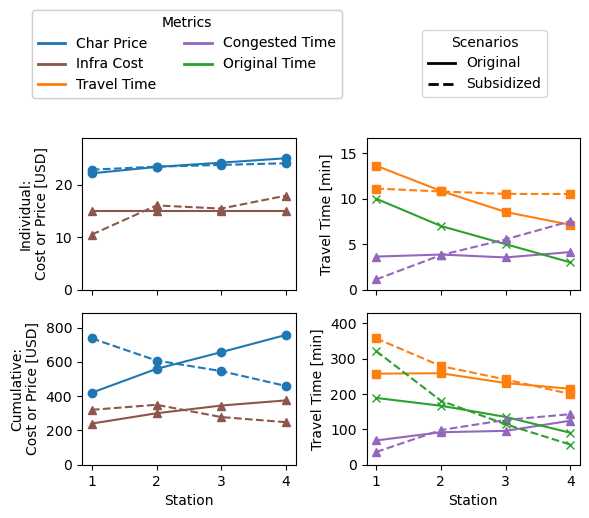

In [6]:
mpl.rcParams['pdf.fonttype'] = 42  # TrueType
mpl.rcParams['ps.fonttype'] = 42   # TrueType

stations, caps, flows, tt, prices, t0, cong = load_results(
    "results_final/nash/NASH_lam0.6_tau0.5_alpha20_oper5_fix15_maxcap100_tax0_0_0_0"
)

TAU = 0.5
INFRA_COST = 15
infra_cost_list = [INFRA_COST] * len(flows)
subsidized_infra_cost = [10.51, 16.07, 15.48, 17.94]

# --- Basic stats ---
avg_tt = sum(tt[i] * flows[i] for i in range(len(flows))) / sum(flows)
print("Average travel time:", avg_tt)
print("Accumulative travel time:", sum(tt[i] * flows[i] for i in range(len(flows))))
print("Revenue at each station:", [prices[i] * flows[i] for i in range(len(flows))])
print("Total revenue:", sum(prices[i] * flows[i] for i in range(len(flows))))
print("Profit at each station:", [prices[i] * flows[i] - INFRA_COST * caps[i] for i in range(len(flows))])

# --- Plot ---
fig, ax = plt.subplots(2, 2, figsize=(6, 4), dpi=100, sharex=True)
# add pad between subplots

plt.subplots_adjust(hspace=0.3, wspace=0.3)

ax = ax.ravel()

# --- Panel 1: Price / Time ---
x = range(1, len(stations) + 1)
ax[0].plot(stations, prices, marker="o", label="Price", color="tab:blue")
ax[0].plot(stations, infra_cost_list, marker="^", label="Travel Time", color="tab:brown")
ax[0].set_ylabel("Individual:\nCost or Price [USD]")

ax[1].plot(stations, cong, marker="^", label="Congested Time", color="tab:purple")
ax[1].plot(stations, t0, marker="x", label="Original Time", color="tab:green")
ax[1].plot(stations, tt, marker="s", label="Travel Time", color="tab:orange")

ax[1].set_ylabel("Travel Time [min]")

# --- Panel 2: Costs / Revenues ---
ax[2].plot(stations, [prices[i] * flows[i] for i in range(len(flows))], marker="o", label="Revenue", color="tab:blue")
ax[2].plot(
    stations,
    [INFRA_COST * caps[i] for i in range(len(flows))],
    marker="^",
    label="Infrastructure Cost",
    color="tab:brown",
)

ax[3].plot(
    stations,
    [tt[i] * flows[i] for i in range(len(flows))],
    marker="s",
    label="Travel Time",
    color="tab:orange",
)

ax[3].plot(
    stations,
    [cong[i] * flows[i] for i in range(len(flows))],
    marker="^",
    label="Congested Time",
    color="tab:purple",
)
ax[3].plot(
    stations,
    [t0[i] * flows[i] for i in range(len(flows))],
    marker="x",
    label="Original Time",
    color="tab:green",
)

ax[2].set_xlabel("Station")
ax[2].set_ylabel("Cumulative:\nCost or Price [USD]")
ax[2].legend()

# ================== Add Subsidy Scenario ==================
stations, caps, flows, tt, prices, t0, cong = load_results(
    r"results_final/subsidy/SUBSIDY_tau0.5_alpha20_lam0.6_demand100"
)

# Panel 1 with subsidy
ax[0].plot(stations, prices, marker="o", linestyle="--", label="Subsidized Price", color="tab:blue")
ax[0].plot(
    stations,
    subsidized_infra_cost,
    marker="^",
    linestyle="--",
    color="tab:brown",
)
ax[1].plot(stations, tt, marker="s", linestyle="--", label="Travel Time w/ Subsidy", color="tab:orange")
ax[1].plot(stations, cong, marker="^", linestyle="--", label="Congested Time w/ Subsidy", color="tab:purple")
# ax[0].plot(stations, t0, marker="x", linestyle='--',
#            label="Original Time w/ Subsidy", color="tab:green")

# Panel 2 with subsidy
ax[2].plot(
    stations,
    [prices[i] * flows[i] for i in range(len(flows))],
    marker="o",
    linestyle="--",
    label="Revenue w/ Subsidy",
    color="tab:blue",
)

ax[2].plot(
    stations,
    [subsidized_infra_cost[i] * caps[i] for i in range(len(flows))],
    marker="^",
    linestyle="--",
    label="Infra Cost w/ Subsidy",
    color="tab:brown",
)

ax[3].plot(
    stations,
    [tt[i] * flows[i] for i in range(len(flows))],
    marker="s",
    linestyle="--",
    label="Travel Time w/ Subsidy",
    color="tab:orange",
)
ax[3].plot(
    stations,
    [cong[i] * flows[i] for i in range(len(flows))],
    marker="^",
    linestyle="--",
    label="Congested Time w/ Subsidy",
    color="tab:purple",
)
ax[3].plot(
    stations,
    [t0[i] * flows[i] for i in range(len(flows))],
    marker="x",
    linestyle="--",
    label="Original Time w/ Subsidy",
    color="tab:green",
)
ax[3].set_ylabel("Travel Time [min]")
ax[3].set_xlabel("Station")

from matplotlib.lines import Line2D

# Define custom legend entries
color_legend = [
    Line2D([0], [0], color="tab:blue", lw=2, label="Char Price"),
    Line2D([0], [0], color="tab:brown", lw=2, label="Infra Cost"),
    Line2D([0], [0], color="tab:orange", lw=2, label="Travel Time"),
    Line2D([0], [0], color="tab:purple", lw=2, label="Congested Time"),
    Line2D([0], [0], color="tab:green", lw=2, label="Original Time"),
    # Line2D([0], [0], color="tab:red", lw=2, label="Revenue"),
]

style_legend = [
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Original"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Subsidized"),
]

# Combine legends
first_legend = fig.legend(handles=color_legend, title="Metrics", loc="upper left", ncol = 2, bbox_to_anchor=(0.05, 1.3))
fig.add_artist(first_legend)

fig.legend(handles=style_legend, title="Scenarios", loc="upper left", bbox_to_anchor=(.7, 1.25))

# remove legend in other subplots
for i in [0, 2, 3]:
    ax[i].legend().remove()

ax[0].set_ylim(0, max(prices)*1.2)
ax[1].set_ylim(0, max(tt)*1.5)
ax[2].set_ylim(0, max([prices[i] * flows[i] for i in range(len(flows))]) * 1.2)
ax[3].set_ylim(0, max([tt[i] * flows[i] for i in range(len(flows))]) * 1.2)


plt.tight_layout() # leave space for legend rect=[0, 0, 1, 0.9]
plt.savefig("subsidy_plot_2_2.pdf", bbox_inches='tight', dpi=300)